[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Boyu-Zhang-UOI/pml-f2026-notebooks/blob/main/03-classical-ml/02_regularization_bias_variance.ipynb)

# Capacity, Curves, and Two Penalties

**Session 9 · companion to HW 2 · nothing here is a homework answer**

Session 9 asks one question in four ways: *is this model too simple or too
complicated for the data I have?* The answer is never a single score. It is a
curve — over model capacity, over training-set size, or over a regularization
strength — and reading those curves is the skill.

One dataset throughout, so every comparison is like for like.

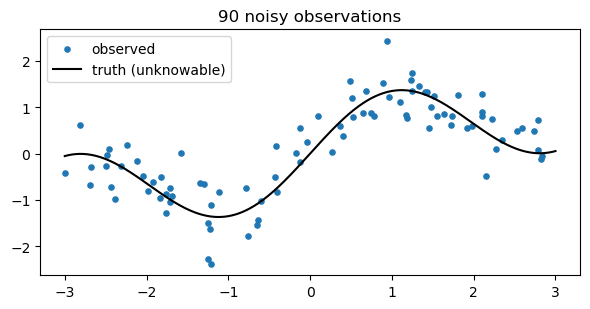

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(3)

def truth(x):
    return np.sin(1.6 * x) + 0.35 * x          # the function we are trying to recover

n = 90
x = np.sort(rng.uniform(-3, 3, n))
y = truth(x) + rng.normal(0, 0.45, n)
X = x.reshape(-1, 1)

grid = np.linspace(-3, 3, 400).reshape(-1, 1)
plt.figure(figsize=(6, 3.2))
plt.scatter(x, y, s=14, label="observed")
plt.plot(grid, truth(grid.ravel()), color="black", lw=1.5, label="truth (unknowable)")
plt.legend(); plt.title(f"{n} noisy observations"); plt.tight_layout(); plt.show()

## Capacity: the same data, eleven model sizes

A polynomial of degree *d* is a dial for capacity. Turn it up and the training
error falls monotonically — it must, since a bigger model contains the smaller
one. Whether the *validation* error follows is the entire question.

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=0)

degrees = range(1, 16)
train_rmse, valid_rmse = [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    model.fit(X_train, y_train)
    train_rmse.append(mean_squared_error(y_train, model.predict(X_train)) ** 0.5)
    valid_rmse.append(mean_squared_error(y_valid, model.predict(X_valid)) ** 0.5)

best = int(np.argmin(valid_rmse)) + 1
for d, tr, va in zip(degrees, train_rmse, valid_rmse):
    mark = "  <- best on validation" if d == best else ""
    print(f"degree {d:>2}   train {tr:.3f}   validation {va:.3f}{mark}")

degree  1   train 0.801   validation 0.710
degree  2   train 0.801   validation 0.708
degree  3   train 0.552   validation 0.517
degree  4   train 0.552   validation 0.516  <- best on validation
degree  5   train 0.406   validation 0.574
degree  6   train 0.403   validation 0.580
degree  7   train 0.396   validation 0.552
degree  8   train 0.396   validation 0.554
degree  9   train 0.391   validation 0.575
degree 10   train 0.382   validation 0.569
degree 11   train 0.378   validation 0.571
degree 12   train 0.373   validation 0.586
degree 13   train 0.373   validation 0.586
degree 14   train 0.370   validation 0.568
degree 15   train 0.356   validation 0.566


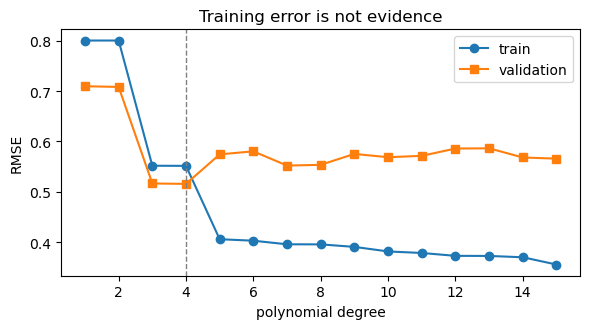

In [3]:
plt.figure(figsize=(6, 3.4))
plt.plot(list(degrees), train_rmse, "o-", label="train")
plt.plot(list(degrees), valid_rmse, "s-", label="validation")
plt.axvline(best, color="grey", ls="--", lw=1)
plt.xlabel("polynomial degree"); plt.ylabel("RMSE"); plt.legend()
plt.title("Training error is not evidence"); plt.tight_layout(); plt.show()

The two curves separate: training error keeps falling, validation error turns
around. Everything to the right of the dashed line is capacity spent on the
noise in these particular ninety points.

Look at what that means for the fitted function:

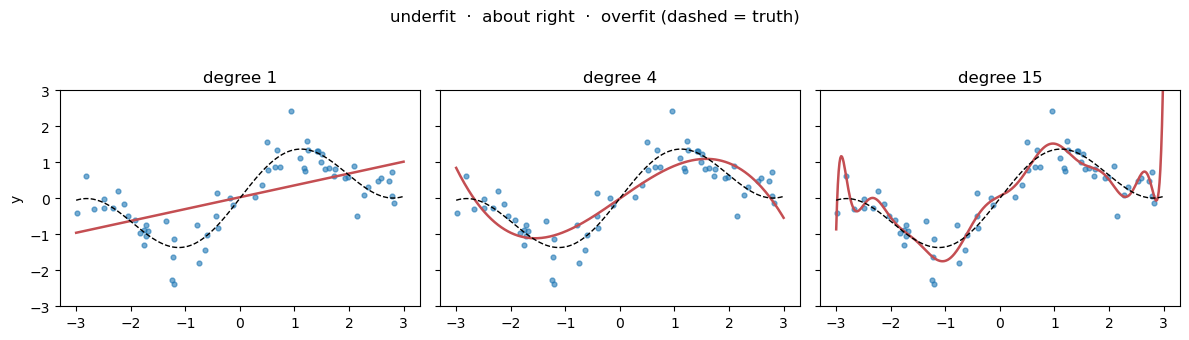

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, d in zip(axes, [1, best, 15]):
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(X_train, y_train)
    ax.scatter(X_train, y_train, s=12, alpha=.6)
    ax.plot(grid, model.predict(grid), color="#C44E52", lw=1.8)
    ax.plot(grid, truth(grid.ravel()), color="black", lw=1, ls="--")
    ax.set_title(f"degree {d}")
    ax.set_ylim(-3, 3)
axes[0].set_ylabel("y")
fig.suptitle("underfit  ·  about right  ·  overfit (dashed = truth)", y=1.05)
plt.tight_layout(); plt.show()

Degree 1 cannot bend. Degree 15 bends through individual points and then leaves
the data behind entirely at the edges — the classic signature, and the reason
extrapolation from a high-degree polynomial is never safe.

## Learning curves: more data, or a different model?

The capacity curve varies the model with the data fixed. The learning curve
varies the data with the model fixed, and it answers the question that actually
comes up in a project: *would collecting more rows help?*

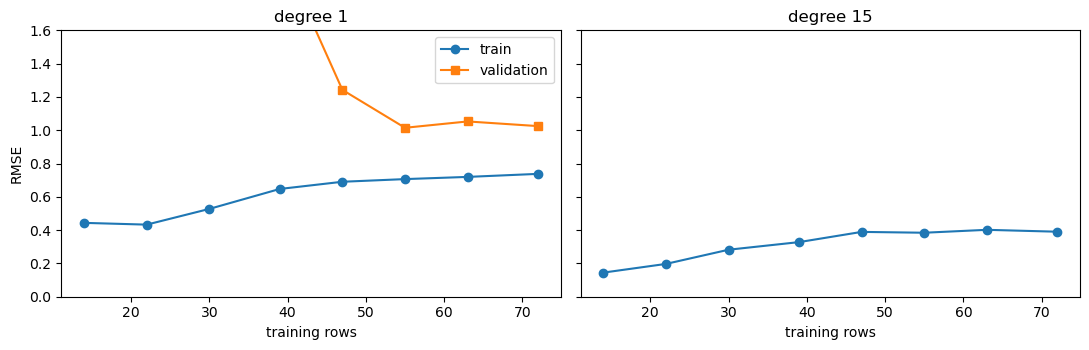

In [5]:
from sklearn.model_selection import learning_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, d in zip(axes, [1, 15]):
    sizes, tr_scores, va_scores = learning_curve(
        make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()),
        X, y, cv=5, train_sizes=np.linspace(0.2, 1.0, 8),
        scoring="neg_root_mean_squared_error", random_state=0)
    ax.plot(sizes, -tr_scores.mean(1), "o-", label="train")
    ax.plot(sizes, -va_scores.mean(1), "s-", label="validation")
    ax.set_title(f"degree {d}")
    ax.set_xlabel("training rows")
    ax.set_ylim(0, 1.6)
axes[0].set_ylabel("RMSE"); axes[0].legend()
plt.tight_layout(); plt.show()

Two shapes, two prescriptions:

- **Degree 1 (left):** the curves meet, high, and flatten. The model has already
  learned everything it is capable of learning. More rows will not help; a model
  with more capacity will.
- **Degree 15 (right):** a wide gap that is still closing at the right edge. The
  model can represent the truth but has too little data to pin it down. Here
  more rows *would* help — and so would a penalty, which is the cheaper option.

That is the whole diagnostic. "More data or a better model?" is answered by the
gap and the slope, not by intuition.

## Two penalties

Ridge shrinks every coefficient toward zero. Lasso shrinks too, but its
geometry lets coefficients arrive *at* zero and stay there, which makes it a
selector as well as a regularizer.

In [6]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import cross_val_score

alphas = np.logspace(-3, 3, 40)   # below 1e-3, coordinate descent on 15 poly
                                  # features stops converging and says so loudly
ridge_scores, lasso_scores = [], []
for a in alphas:
    ridge_scores.append(cross_val_score(
        make_pipeline(PolynomialFeatures(15), StandardScaler(), Ridge(alpha=a)),
        X_train, y_train, cv=5, scoring="neg_root_mean_squared_error").mean())
    lasso_scores.append(cross_val_score(
        make_pipeline(PolynomialFeatures(15), StandardScaler(), Lasso(alpha=a, max_iter=50_000)),
        X_train, y_train, cv=5, scoring="neg_root_mean_squared_error").mean())

best_ridge = alphas[int(np.argmax(ridge_scores))]
best_lasso = alphas[int(np.argmax(lasso_scores))]
print(f"degree-15 model, alpha chosen by 5-fold CV on the TRAINING split only")
print(f"  ridge: alpha = {best_ridge:.4g}   CV RMSE = {-max(ridge_scores):.3f}")
print(f"  lasso: alpha = {best_lasso:.4g}   CV RMSE = {-max(lasso_scores):.3f}")
print(f"  unpenalised degree 15, same CV     = "
      f"{-cross_val_score(make_pipeline(PolynomialFeatures(15), StandardScaler(), LinearRegression()), X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean():.3f}")

degree-15 model, alpha chosen by 5-fold CV on the TRAINING split only
  ridge: alpha = 0.2894   CV RMSE = 0.506
  lasso: alpha = 0.005878   CV RMSE = 0.479
  unpenalised degree 15, same CV     = 0.772


A degree-15 model with the right penalty beats the same model without one, and
it does so without anybody choosing the degree. That is the argument for
regularization in one line: **you no longer have to guess the capacity, only the
penalty** — and the penalty is a continuous dial that cross-validation can turn
for you.

## Coefficient paths

Watch what the two penalties do to the coefficients as alpha grows.

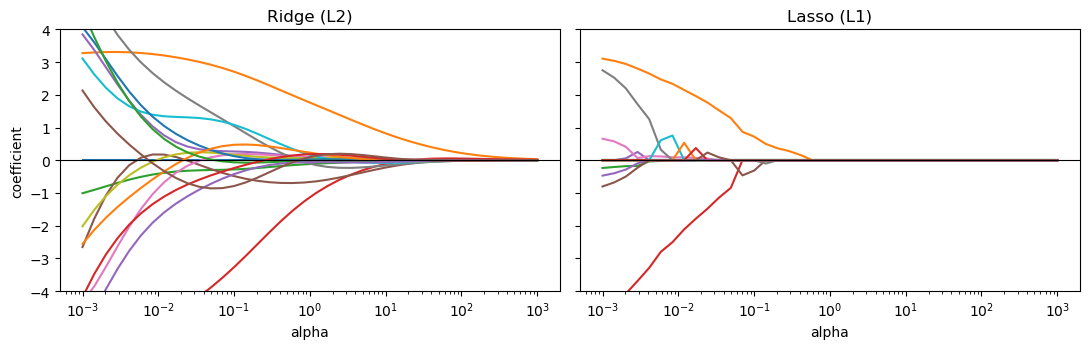

ridge: coefficients exactly zero at the smallest alpha = 1, at the largest = 1 of 16
lasso: coefficients exactly zero at the smallest alpha = 9, at the largest = 16 of 16


In [7]:
poly = PolynomialFeatures(15)
scaler = StandardScaler()
Z_train = scaler.fit_transform(poly.fit_transform(X_train))

ridge_path = np.array([Ridge(alpha=a).fit(Z_train, y_train).coef_ for a in alphas])
lasso_path = np.array([Lasso(alpha=a, max_iter=50_000).fit(Z_train, y_train).coef_ for a in alphas])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, path, name in zip(axes, [ridge_path, lasso_path], ["Ridge (L2)", "Lasso (L1)"]):
    ax.plot(alphas, path)
    ax.set_xscale("log"); ax.set_xlabel("alpha"); ax.set_title(name)
    ax.axhline(0, color="black", lw=.8)
    ax.set_ylim(-4, 4)
axes[0].set_ylabel("coefficient")
plt.tight_layout(); plt.show()

for name, path in (("ridge", ridge_path), ("lasso", lasso_path)):
    exact_zeros = (np.abs(path) < 1e-10).sum(axis=1)
    print(f"{name}: coefficients exactly zero at the smallest alpha = {exact_zeros[0]}, "
          f"at the largest = {exact_zeros[-1]} of {path.shape[1]}")

Ridge coefficients decay toward zero and arrive only in the limit. Lasso
coefficients hit zero at a finite alpha and stay there — which is why lasso is
described as performing selection: the count above is the number of features it
has switched off entirely.

(Ridge's one exact zero at every alpha is the constant column that
`PolynomialFeatures` adds. `StandardScaler` maps a column with no variance to
all zeros, so its coefficient is zero for arithmetic reasons rather than for
statistical ones. Worth noticing once, then ignoring.)

## Why scaling is not optional here

A penalty of the form `alpha * ||w||` is a statement about the size of the
coefficients, and the size of a coefficient depends on the units of its feature.
Change a feature from metres to millimetres and its coefficient shrinks by a
thousand — so the penalty stops applying to it.

In [8]:
rng2 = np.random.default_rng(0)
n2 = 200
A = rng2.normal(0, 1, n2)
B = rng2.normal(0, 1, n2) * 0.001              # same information, different units
target = 2.0 * A + 2000.0 * B + rng2.normal(0, 0.1, n2)
M = np.column_stack([A, B])

unscaled = Ridge(alpha=10).fit(M, target)
scaled = make_pipeline(StandardScaler(), Ridge(alpha=10)).fit(M, target)

print("both features carry the same signal: 2.0 * A and 2000 * B contribute equally\n")
print(f"unscaled ridge coefficients: {unscaled.coef_.round(3)}")
print(f"scaled ridge coefficients  : {scaled[-1].coef_.round(3)}")
print(f"\ntraining R^2  unscaled: {unscaled.score(M, target):.4f}   scaled: {scaled.score(M, target):.4f}")

both features carry the same signal: 2.0 * A and 2000 * B contribute equally

unscaled ridge coefficients: [1.772 0.042]
scaled ridge coefficients  : [1.831 1.953]

training R^2  unscaled: 0.4318   scaled: 0.9961


Feature `B` is measured in units a thousand times smaller, so fitting it
requires a coefficient a thousand times larger — and `alpha * ||w||^2` charges
for exactly that. Ridge cannot afford the coefficient, so it does not buy the
feature: the unscaled fit sets it to roughly zero and loses the signal, while
the scaled fit gives the two features near-identical weights, which is the truth.

The penalty is a statement about coefficient size. Coefficient size is a
statement about units. Standardize first and the penalty means what you think
it means.

## Reading the decomposition correctly

Session 9 presents expected squared error as bias² + variance + irreducible
noise. Two limits on that statement, both worth saying out loud:

- It is a statement about the **expected squared error** of an estimator over
  repeated samples. It is not a per-sample identity, and it does not carry over
  unchanged to accuracy, AUC, or any other metric.
- The three terms are not separately measurable on your one dataset. You can
  *simulate* them, as below, only because we know the truth here — which in a
  real project you do not.

## What to take from this

- Training error falling is not evidence of anything. Two curves, or none.
- The learning-curve shape answers "more data or a better model?" — gap that is
  still closing means data, curves that have met means capacity.
- Regularization replaces a discrete guess (which degree?) with a continuous one
  (which alpha?), and cross-validation can search the second.
- Lasso zeroes coefficients exactly; ridge only approaches zero.
- Scale before you penalise, or the penalty applies unevenly for no reason but
  units.
- Alpha is chosen on training folds. The test set has not been touched in this
  notebook.

## Where to go next

- **Reading, Session 9** — the decomposition, learning curves, and the pitfalls.
- **HW 2** — asks for the closed-form ridge solution and a gradient descent that
  finds it. Neither is implemented here.